In [32]:
import os 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet
from DCGAN.discriminator import Discriminator

from CityScapes.datasets import CityScapesMultiResolutionDataset
from DCGAN.loss_functions import EntropyLoss, DriftLoss, WeightedMSELoss, TotalVariationLoss
from DCGAN.loss_functions import SoftRoutingLoss, DilatedReconstructionLoss
device ="cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5)

In [ ]:
n_components= 4


z_dim =256
encoder_channels = [512,256,128,64,32,32,16]
decoder_channels = [256,128,64,32,16,16,8]
discriminator_channels =  [512,256,128,64,32,32,16]
 

rgb_depth = [0,1,1,2,2,2,2]
degrees_of_freedom = [256,128,64,32,4,4,4]
vectorizer_output_channels = [16,8,4,4,2,2] 
grid_sizes = [1, 2, 4, 4,4,4] 

seg_gen_cut_connections = 2

batch_size = 32
rec_model_lr = 1.0e-4
seg_model_lr = 1.0e-5
disc_model_lr  = 1.0e-5

intra_loss_weight = 0.002
inter_loss_weight = 0.001

In [49]:
msg_dataset = CityScapesMultiResolutionDataset()
train_loader = DataLoader(msg_dataset, batch_size=batch_size, shuffle=True)

Dataset initialized with 19998 samples. Labels enabled: False


In [35]:

rec_model = VectorizedUNet(encoder_channels=encoder_channels,
                           decoder_channels=decoder_channels,
                           number_of_components=n_components,
                           vectorizer_output_channels=vectorizer_output_channels,
                           grid_sizes=grid_sizes,
                           degrees_of_freedom = degrees_of_freedom,
                           z_dim=z_dim,
                           rgb_depth=rgb_depth).to(device)

rec_model_optimizer = optim.Adam(rec_model.parameters(), lr=rec_model_lr)


In [36]:
seg_model = UNet(channels=encoder_channels,
                 out_channels=n_components,
                 cut_connections=seg_gen_cut_connections).to(device)

seg_model_optimizer = optim.Adam(seg_model.parameters(), lr=seg_model_lr)

In [37]:
discriminator = Discriminator(channels=discriminator_channels).to(device)

disc_optimizer= optim.Adam(discriminator.parameters(), lr=disc_model_lr)

/tmp/ipykernel_737723/2410296119.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


tensor(-0.3119, device='cuda:0') tensor(-0.1540, device='cuda:0')


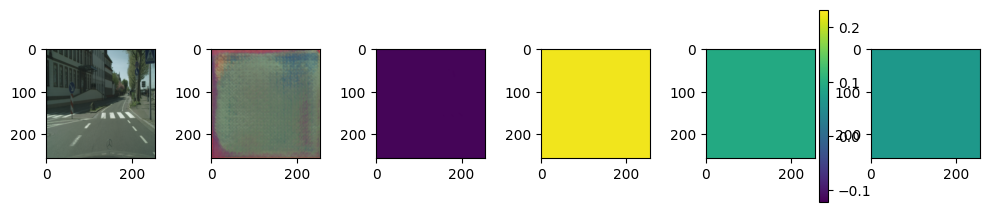

In [38]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg_logits = seg_model(x)
    seg_probs = torch.softmax(seg_logits,dim=1)
    y= rec_model(x,seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



vmin = seg_logits[0].min().item()
vmax = seg_logits[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(seg_logits[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()
print(x.mean(),y[-1].mean())

In [39]:
reconstruction_loss_fn  = nn.MSELoss()

In [40]:
# # pretrain the rec_model to be good all over the place

# epochs =2


# for epoch in range(0, epochs):
#     loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
#     for data,_ in loop:

#         # train discriminator
#         disc_optimizer.zero_grad()

#         # train rec_model
        
#         rec_model_optimizer.zero_grad()

#         full_img = data[-1].to(device)
#         b,_,h,w = full_img.shape
#         dummy_seg_logits = torch.ones(b,n_components,h,w,requires_grad=True).to(device)
#         dummy_seg_probs=  F.softmax(dummy_seg_logits, dim=1)
#         reconstructions= rec_model(full_img,dummy_seg_probs)
        

#         recon_loss = 0
#         for target_img, pred_img in zip(data, reconstructions):
#             target_img = target_img.to(device)
#             recon_loss += reconstruction_loss_fn(pred_img, target_img)
            
        
#         intra_loss, inter_loss = rec_model.similarity_losses()
#         vector_similarity_loss = intra_loss_weight * intra_loss + inter_loss_weight * inter_loss
        
#         loss = recon_loss + vector_similarity_loss

#         loss.backward()
#         rec_model_optimizer.step()

#         loop.set_postfix(
#             recon_loss=recon_loss.item(),
#             similarity_loss=vector_similarity_loss.item(),
#         )
#     rec_model.eval()                                                                                                                                                
#     torch.save(rec_model.state_dict(), f'rec_model.pt')
        



tensor(-0.3119, device='cuda:0') tensor(-0.1533, device='cuda:0')


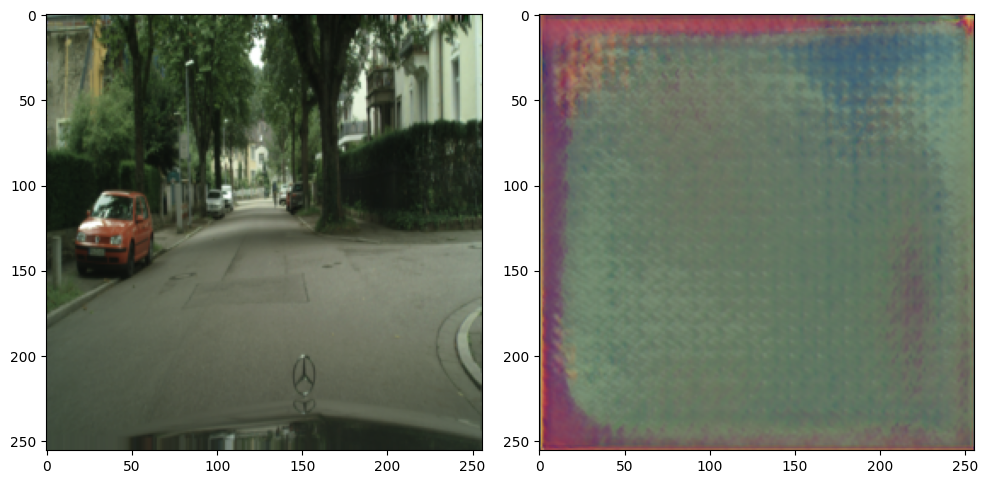

In [41]:
data,_ = next(iter(train_loader)) 
with torch.no_grad():
    full_img = data[-1].to(device)
    b,_,h,w = full_img.shape

    dummy_seg_logits = torch.ones(b,n_components,h,w,requires_grad=True).to(device)
    dummy_seg_probs = torch.softmax(dummy_seg_logits,dim=1)
    y= rec_model(full_img,dummy_seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2,figsize=(10,5))


show  = 1
scaled_x = scale_for_display(data[-show])
sclaed_y = scale_for_display(y[-show])

ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())


vmin = seg_probs[0].min().item()
vmax = seg_probs[0].max().item()

plt.tight_layout()
print(x.mean(),y[-1].mean())

In [88]:
entropy_loss_fn = EntropyLoss(weight=0.01)
tv_loss_fn = TotalVariationLoss(weight=0.01) #
routing_loss_fn = SoftRoutingLoss(weight=1.0)
dilated_reconstruction_loss_fn = DilatedReconstructionLoss(dilation_kernel_size=3,weight=10.0)

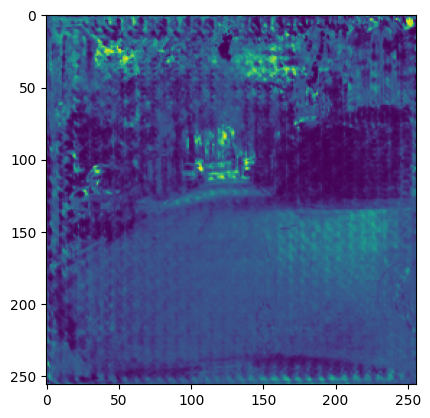

In [43]:
independent_reconstructions = rec_model(full_img, seg_probs=None)
routing_targets = routing_loss_fn.get_targets(independent_reconstructions[-1], full_img, seg_logits)

plt.imshow(routing_targets[0][0].cpu())

In [ ]:
epochs =10

for epoch in range(0, epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for data,_ in loop:
        # generate the data
        
        full_img = data[-1].to(device)
        data= [d.to(device) for d in data]
        seg_logits = seg_model(full_img)
        seg_probs=  F.softmax(seg_logits, dim=1)
        smoothing_factor = 0.2
        if smoothing_factor > 0:
            N = seg_probs.size(1)
            seg_probs = (seg_probs * (1.0 - smoothing_factor)) + (smoothing_factor / N)
            
        reconstructions= rec_model(full_img,seg_probs)

        # ====================================================================
        # B. TRAIN DISCRIMINATOR
        # ====================================================================
        disc_optimizer.zero_grad()

        # Discriminator pass on Reals
        d_real_logits = discriminator(data)
        
        # Discriminator pass on Fakes (DETACHED so gradients don't flow to G)
        fakes_detached = [f.detach() for f in reconstructions]
        d_fake_logits = discriminator(fakes_detached)

        # Hinge Loss for Discriminator
        disc_loss_real = torch.mean(F.relu(1.0 - d_real_logits))
        disc_loss_fake = torch.mean(F.relu(1.0 + d_fake_logits))

        drift_loss = (torch.mean(d_real_logits ** 2) + torch.mean(d_fake_logits ** 2))/1000
        disc_loss = disc_loss_real + disc_loss_fake + drift_loss

        disc_loss.backward()
        disc_optimizer.step()


        # ====================================================================
        # C. TRAIN GENERATOR (seg_model + rec_model)
        # ====================================================================

        seg_model_optimizer.zero_grad()
        rec_model_optimizer.zero_grad()

        g_fake_logits = discriminator(reconstructions)
        adv_loss = -torch.mean(g_fake_logits) # G wants D to output positive 
        adv_loss  = 0.1 * adv_loss
        # B. Entropy Loss (forces masks to be confident/binary)
        # Passes logits for numerical stability!
        entropy_loss = entropy_loss_fn(seg_logits)
        
        # C. Total Variation Loss (forces masks to be smooth blobs)
        # Passes probabilities!
        tv_loss = tv_loss_fn(seg_probs)
        # 5. Combine and Backpropagate
        intra_loss, inter_loss = rec_model.similarity_losses()
        vector_similarity_loss = intra_loss_weight * intra_loss + inter_loss_weight * inter_loss
        
        independent_reconstructions = rec_model(full_img, seg_probs=None)
        routing_loss = routing_loss_fn(independent_reconstructions[-1], full_img, seg_logits)

        dilated_reconstruction_loss= dilated_reconstruction_loss_fn(
                                        independent_reconstructions[-1], 
                                        full_img, 
                                        seg_probs)

        # recon_loss =0
        # for target_img, pred_img in zip(data, reconstructions):
        #     target_img = target_img.to(device)
        #     recon_loss += reconstruction_loss_fn(pred_img, target_img)
        recon_loss =10* reconstruction_loss_fn(reconstructions[-1], full_img)

        loss = (adv_loss + 
                entropy_loss + 
                tv_loss + 
                vector_similarity_loss +
                routing_loss+
                dilated_reconstruction_loss+
                recon_loss)

        loss.backward()
        seg_model_optimizer.step()
        rec_model_optimizer.step()

        loop.set_postfix(
            adv_loss=adv_loss.item(),
            entropy_loss=entropy_loss.item(),
            tv_loss=tv_loss.item(),
            loss=loss.item(),
            similarity_loss = vector_similarity_loss.item(),
            routing_loss = routing_loss.item(),
            dilated_reconstruction_loss=dilated_reconstruction_loss.item(),
            disc_loss= disc_loss.item(),
            recon_loss=recon_loss.item()
        )
    torch.save(seg_model.state_dict(), f'seg_model.pt')
    torch.save(rec_model.state_dict(), f'rec_model.pt')
    torch.save(discriminator.state_dict(), f'discriminator.pt')

Epoch 0/10:  13%|█▎        | 83/625 [01:15<08:12,  1.10it/s, adv_loss=0.066, dilated_reconstruction_loss=0.263, disc_loss=1.72, entropy_loss=0.0105, loss=1.57, recon_loss=0.181, routing_loss=1.05, similarity_loss=0.000728, tv_loss=9.86e-5]  


KeyboardInterrupt: 

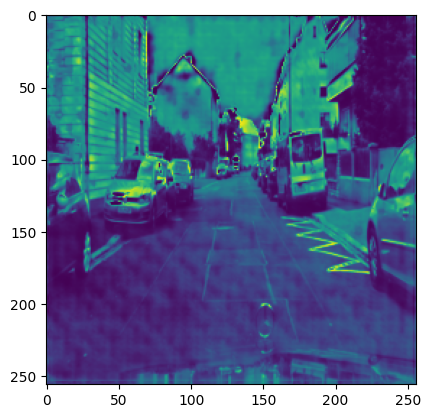

In [ ]:
routing_targets = routing_loss_fn.get_targets(independent_reconstructions[-1], full_img, seg_logits)
                                                                                                                                                                                                                            
plt.imshow(routing_targets[0][0].cpu())

0.2952641546726227
0.3847769498825073
0.04366150125861168
0.276297390460968
tensor(-0.3768, device='cuda:0') tensor(-0.3964, device='cuda:0')


/tmp/ipykernel_737723/2332725506.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


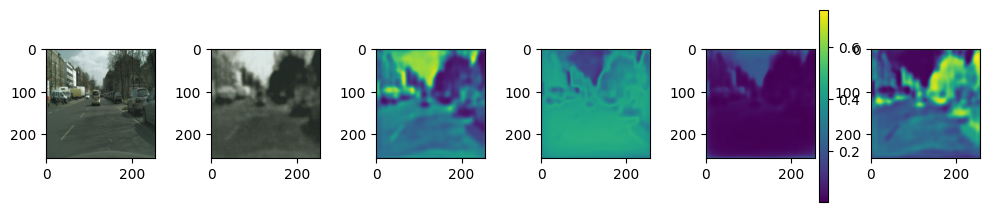

In [100]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    
    seg_probs = torch.softmax(seg,dim=1)
    y= rec_model(x,seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



vmin = seg_probs[0].min().item()
vmax = seg_probs[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(seg_probs[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)
    print(seg_probs[0, i].cpu().numpy().mean().item())
fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()
print(x.mean(),y[-1].mean())

0.22635670006275177
0.3472628891468048
0.06356780976057053
0.3628126084804535


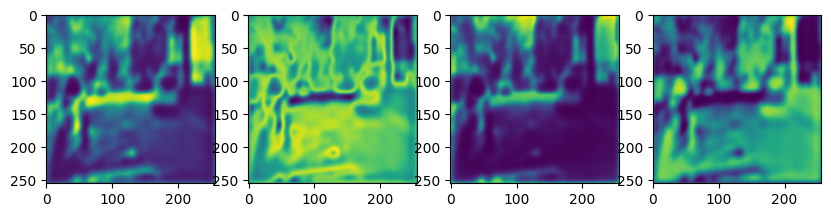

In [94]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)

fig,ax = plt.subplots(1,components,figsize=(10,10))
for i in range(components):
    # Let matplotlib auto-scale the tiny decimal variations
    im = ax[i].imshow(seg_probs[0, i].cpu().numpy()) 
    print(seg_probs[0, i].cpu().numpy().mean().item())

-0.339530885219574 -0.3831932246685028 0.043662331998348236


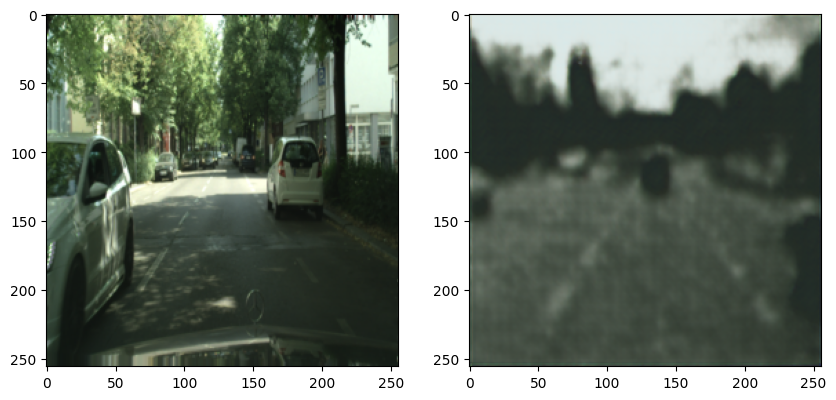

In [ ]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)
    y= rec_model(x,seg_probs)


fig,ax = plt.subplots(1,2,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



print(x.mean().item(),y[-1].mean().item(),(x-y[-1]).mean().item())